## 牛顿法的优化与进阶

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("success")

success


### 牛顿法与梯度下降
   -  优化牛顿法 <==>  对导数做牛顿求根

In [2]:
def f(x):
    return (x - 3.0) ** 2 + 1


def fp(x):
    return 2 * (x - 3)


def fpp(x):
    return 2.0


x0 = 0.0

x_gd, x_nt = x0, x0
eta = 0.15
print("真值 x*= 3")
print("步 | 梯度下降 | 牛顿法")
for i in range(8):
    x_gd = x_gd - eta * fp(x_gd)
    x_nt = x_nt - fp(x_nt) / fpp(x_nt)
    print(f'{i + 1:2d}|{x_gd:.4f}|{x_nt:.2f}')


真值 x*= 3
步 | 梯度下降 | 牛顿法
 1|0.9000|3.00
 2|1.5300|3.00
 3|1.9710|3.00
 4|2.2797|3.00
 5|2.4958|3.00
 6|2.6471|3.00
 7|2.7529|3.00
 8|2.8271|3.00


### 病态山谷时牛顿法和梯度下降

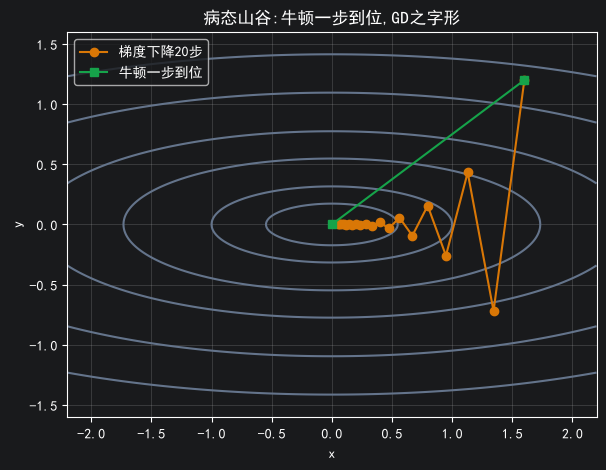

GD终点 [4.89447037e-02 4.38739013e-05] 牛顿终点 [0. 0.]


In [3]:

def path_gd(xy, eta=0.08, steps=20):
    hist = [xy.copy()]
    for _ in range(steps):
        x, y = xy
        g = np.array([2.0 * x, 20.0 * y])
        xy = xy - eta * g
        hist.append(xy.copy())
    return np.array(hist)


def path_nt(xy):
    return np.vstack([xy, np.zeros(2)])


start = np.array([1.6, 1.2])
pg, pn = path_gd(start), path_nt(start)

xs = np.linspace(-2.2, 2.2, 200)
ys = np.linspace(-1.6, 1.6, 200)

X, Y = np.meshgrid(xs, ys)
Z = X ** 2 + 10 * Y ** 2
plt.figure(figsize=(8, 5))
plt.contour(X, Y, Z, levels=[0.3, 1, 3, 6, 12, 20], colors='#64748b')
plt.plot(pg[:, 0], pg[:, 1], 'o-', color='#d97706', label='梯度下降20步')
plt.plot(pn[:, 0], pn[:, 1], 's-', color='#16a34a', label="牛顿一步到位")
plt.legend()
plt.gca().set_aspect('equal')
plt.title('病态山谷:牛顿一步到位,GD之字形')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.show()

print("GD终点", pg[-1], "牛顿终点", pn[-1])


In [4]:
def path_gd_c(xy, c, eta=0.08, steps=15):
    hist = [xy.copy()]
    for i in range(steps):
        x, y = xy
        g = np.array(2.0 * x, 20 * c * y)
        xy = xy - eta * g
        hist.append(xy.copy())
    return np.array(hist)

start = np.array([1.6, 1.2])
for c in [5.0, 10.0, 25.0]:
    p = path_gd_c(start, c)
    print(f'c={c:4.0f} GD 第15步 |y| ={abs(p[-1, 1]):.3e} 牛顿一步到位')

c=   5 GD 第15步 |y| =2.830e-01 牛顿一步到位
c=  10 GD 第15步 |y| =2.830e-01 牛顿一步到位
c=  25 GD 第15步 |y| =2.830e-01 牛顿一步到位


### 逆牛顿直觉

In [5]:
### 逆牛顿直觉

def fp(x):
    return x ** 3 - x


def newton(x, steps=6):
    hist = [x]
    for _ in range(steps):
        h = 3 * x * x - 1
        if abs(h) < 1e-12:
            break
        x = x - fp(x) / h
        hist.append(x)
    return hist


def secant(x0, x1, steps=6):
    hist = [x0, x1]
    for _ in range(steps):
        g0, g1 = fp(x0), fp(x1)

        if abs(g0 - g1) < 1e-12:
            break
        x2 = x1 - g1 * (x1 - x0) / (g1 - g0)
        x0, x1 = x1, x2
        hist.append(x1)
    return hist

print("驻点应该接近 +-1 或者0 ")
print('牛顿 x0=0.8:', [round(v, 6) for v in newton(0.8)])
print('割线0.5,0.8:', [round(v, 6) for v in secant(0.5, 0.8)])
print('牛顿 x0=0.1:', [round(v, 6) for v in newton(0.1)], '<- k靠近0(极大)')

# 二阶找的是驻点不是极值

驻点应该接近 +-1 或者0 
牛顿 x0=0.8: [0.8, 1.113043, 1.015175, 1.000334, 1.0, 1.0, 1.0]
割线0.5,0.8: [0.5, 0.8, 1.793103, 0.867138, 0.914708, 1.022814, 0.996857, 0.999895]
牛顿 x0=0.1: [0.1, -0.002062, 0.0, -0.0, 0.0, 0.0, 0.0] <- k靠近0(极大)


In [6]:
# 鞍点
xy_nt = np.array([1.2, 0.8])
g = np.array([2.0 * xy_nt[0], 2.0 * xy_nt[1]])
H = np.array([[2.0, 0.0], [0.0, -2.0]])
xy_nt_next = xy_nt - np.linalg.solve(H, g)
print('牛顿一步:', xy_nt, '-->', xy_nt_next)

牛顿一步: [1.2 0.8] --> [0.  1.6]


In [7]:
xy = np.array([1.2, 0.8], dtype=float)
print("GD eta =0.8")
for i in range(6):
    g = np.array([2.0 * xy[0], -2.0 * xy[1]])
    xy = xy - 0.08 * g
    print(f' 第{i + 1}步{xy}')


GD eta =0.8
 第1步[1.008 0.928]
 第2步[0.84672 1.07648]
 第3步[0.7112448 1.2487168]
 第4步[0.59744563 1.44851149]
 第5步[0.50185433 1.68027333]
 第6步[0.42155764 1.94911706]


###  作业1: 改参数(cell 3): c 改成 50, 看GD的y是否爆炸?

In [8]:
p = path_gd_c(start, c=50)

print(f'c={c:4.0f} GD 第15步 |y| ={abs(p[-1, 1]):.3e} 牛顿一步到位')

c=  25 GD 第15步 |y| =2.830e-01 牛顿一步到位


### 作业2: coding 出牛顿法、泰勒展开、麦克劳林、拟牛顿、XGBoost、LightGBM的动态运行图, 每个理论方法需要附上不少于200字的观察与理解, 格式采用html+css

### 牛顿法
- 观察:
    1. 未使用阻尼系数(0),二阶导数为负值的时候会移动到极大点
    2. 使用阻尼系数后(0.1),下降路径呈现之字形下降,退化为梯度下降(病态山谷)
    3. 下降的幅度,与图形的弯曲程度有关, 弯曲程度大且光滑, 相对下降幅度就大
    4.  当初始点处于最优值周围才可以收敛,当落在鞍点会导致无法继续收敛
- 思考:
    牛顿法是通过二阶导数来寻找极值,一阶为下降方向,二阶弯曲程度,优点是收敛速度快,且在最优点附近不会下降速度,缺点要计算二阶导数成本高,且还有一些限制,例如处于鞍点就会导致无法收敛,函数的最优值必须就离初始值较近(不能越过鞍点,或者极大值)

### 泰勒展开
- 观察:
    1. 当提高展开阶数,在展开中心处的拟合曲线更加贴近原函数
    2. 距离展开中心越远,即使提高阶数,也无法做到与原函数拟合,且距离越大误差越明显
    3. 距离展开中心越近拟合程度越高
- 思考
    1. 泰勒展开无法通过一个点,提高展开阶数的方法,实现对一个函数的模拟, 可以在函数上取多个点,从多个部分合并拟合原始函数
    2. 泰勒展开的给求解超越函数提供的了方向,无限逼近值近似求解原函数值
    3. 展开式需要不断的n阶求导,这个对于获取更高精度,需要的运算量仍然巨大

### 麦克劳林
- 观察
    1. 麦克劳林的图像与泰勒展开基本一致,只是展开中心固定在0点处
    2. 远离观察点时,误差增大
- 思考
    麦克劳林只是泰勒展开式的一种特例,展开中心限定为0

### 拟牛顿
- 观察
    1. 起点距离最优解在一个合理范围中,拟牛顿法不会增加下降更新步数也可以找到对应下降的最低点方向
    2. 拟牛顿法不会像牛顿法一样,按照曲率直接找到最优点,每次只会更新到到最优点之前部分
- 思考
    - 拟牛顿法利用相邻迭代点的梯度变化,更新Hessian,它无法直接到达最优点,一般需要多次
    - 拟牛顿法在有鞍点的时候仍然可以继续找到最优点,不会出现牛顿法在鞍点卡死


### XGBoost
- 观察
    1. 提高树的数量,可以提高树预测值与原数值的拟合准确度
    2. 提高树的深度,也可以高树预测值与原数值的拟合准确度
    3. 学习率较大时，模型更新幅度较大，通常可以更快降低训练误差, 学习率较小时，每轮更新更加谨慎，通常需要更多的树才能达到相近的训练效果。

- 思考
    # TODO 内部具体逻辑暂时不能理解
### LightGBM
- 观察
    # TODO  暂未理解最终实现逻辑

- 思考


